CatBoost is an open-source, high-performance gradient boosting library developed by Yandex that excels at handling categorical features automatically without preprocessing

In [2]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/100.2 MB 2.5 MB/s eta 0:00:40
   ---------------------------------------- 0.8/100.2 MB 2.5 MB/s eta 0:00:40
   ---------------------------------------- 1.0/100.2 MB 1.4 MB/s eta 0:01:09
    --------------------------------------- 1.6/100.2 MB 1.6 MB/s eta 0:01:04
    --------------------------------------- 2.1/100.2 MB 1.7 MB/s eta 0:00:58
    --------------------------------------- 2.4/100.2 MB 1.6 MB/s eta 0:01:01
   - -------------------------------------- 3.1/100.2 MB 1.9 MB/s eta 0:00:53
   - -------------------------------------- 3.1/100.2 MB 1.9 MB/s eta 0:00:53
   - -------------------------------------- 3.4/100.2 MB 1.7 MB/s eta 0:00:56
   - -------------------------------------- 3.7/100.2 MB 1.7 MB/s eta 0:00:58
   - -------------------------------------- 3.7/100.2 MB 1.7 MB/s eta 0:00:58


RMSE: 25.840483957946862


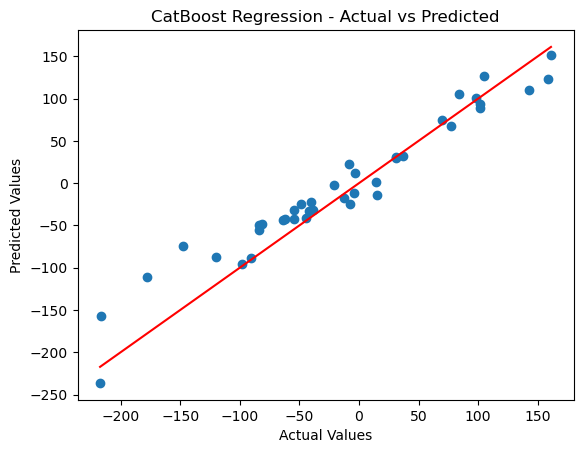

In [3]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Generate dataset
X, y = make_regression(n_samples=200, n_features=5, noise=20, random_state=42)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    verbose=0
)

# Train model
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", rmse)

plt.scatter(y_test, predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("CatBoost Regression - Actual vs Predicted")
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)], color="red")
plt.show()